# Store tiering — Rossmann (1,115 stores, 2013-01 → 2015-07)

**Goal.** Rank every store into tiers A–D with a transparent, weighted multi-factor score that a
regional manager can challenge store by store.

**Inputs.** `marts.mart_store_features` (built and tested by dbt in the Airflow DAG),
`marts.dim_store`, `marts.fct_sales_daily`. Nothing in this notebook re-derives a metric the
warehouse already defines, so the numbers here match the documented data dictionary.

Sections: 1) data & coverage · 2) EDA · 3) hypothesis test · 4) tiering model · 5) sensitivity ·
6) defending a single store · 7) limitations.

In [1]:
import json, os, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "analytics" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from sales_analytics.tiering import FACTORS, TIER_SHARES, explain_store, score_stores, weight_sensitivity

FIG = ROOT / "analytics" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
RESULTS: dict = {}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg.connect(
    host=os.environ.get("WAREHOUSE_HOST", "localhost"), port=os.environ.get("WAREHOUSE_PORT", "5433"),
    dbname=os.environ.get("WAREHOUSE_DB", "warehouse"), user=os.environ["WAREHOUSE_USER"],
    password=os.environ["WAREHOUSE_PASSWORD"],
)
q = lambda sql: pd.read_sql_query(sql, conn)  # noqa: E731

## 1. Data & coverage

In [2]:
features = q("select * from marts.mart_store_features").set_index("store_id").sort_index()
stores = q("select * from marts.dim_store").set_index("store_id").sort_index()
coverage = q('''
    select count(*) as rows, count(distinct store_id) as stores,
           min(sales_date) as first_day, max(sales_date) as last_day,
           sum(case when is_open then 1 else 0 end) as open_days
    from marts.fct_sales_daily''')
RESULTS["coverage"] = coverage.iloc[0].astype(str).to_dict()
print(coverage.T.to_string(header=False))
print("\nstores missing days:", features["days_missing"].value_counts().sort_index().to_dict())

/var/folders/5n/9yjg326d4wl8pkrk0nfjsy_r0000gn/T/ipykernel_73197/2504478707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q = lambda sql: pd.read_sql_query(sql, conn)  # noqa: E731
/var/folders/5n/9yjg326d4wl8pkrk0nfjsy_r0000gn/T/ipykernel_73197/2504478707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q = lambda sql: pd.read_sql_query(sql, conn)  # noqa: E731
/var/folders/5n/9yjg326d4wl8pkrk0nfjsy_r0000gn/T/ipykernel_73197/2504478707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q = lambda sql: pd.read_

rows          1017209
stores           1115
first_day  2013-01-01
last_day   2015-07-31
open_days      844392

stores missing days: {0: 934, 1: 1, 184: 180}


180 stores are missing every day from 2014-07-01 to 2014-12-31 (and store 988 misses one day).
The pipeline's parity check baselines this gap as a known upstream defect. It is why the
**momentum** factor compares H1-2015 with H1-2014 rather than full years: H1 is the latest
like-for-like window every store has.

/var/folders/5n/9yjg326d4wl8pkrk0nfjsy_r0000gn/T/ipykernel_73197/2504478707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q = lambda sql: pd.read_sql_query(sql, conn)  # noqa: E731


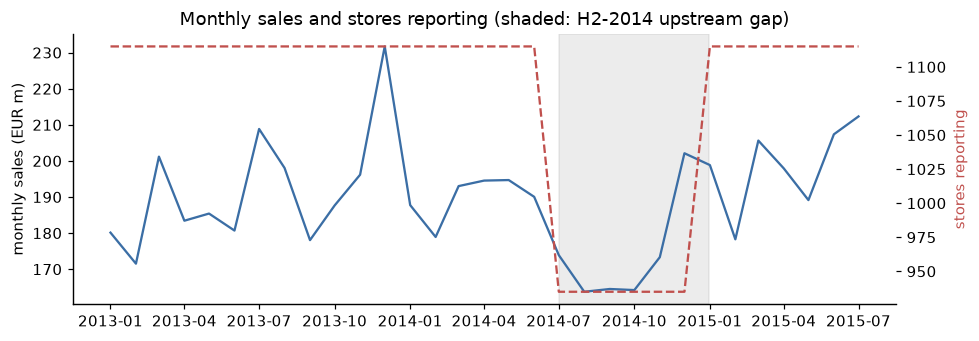

In [3]:
monthly = q('''
    select date_trunc('month', sales_date)::date as month,
           count(distinct store_id) as stores_reporting,
           sum(sales_amount) / 1e6 as sales_m
    from marts.fct_sales_daily group by 1 order by 1''')
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(monthly["month"], monthly["sales_m"], color="#3b6ea5")
ax.set_ylabel("monthly sales (EUR m)")
ax2 = ax.twinx(); ax2.plot(monthly["month"], monthly["stores_reporting"], color="#c0504d", ls="--")
ax2.set_ylabel("stores reporting", color="#c0504d"); ax2.spines["top"].set_visible(False)
ax.axvspan(pd.Timestamp("2014-07-01"), pd.Timestamp("2014-12-31"), color="grey", alpha=.15)
ax.set_title("Monthly sales and stores reporting (shaded: H2-2014 upstream gap)")
fig.tight_layout(); fig.savefig(FIG / "monthly_sales_coverage.png"); plt.show()

## 2. Exploratory analysis

/var/folders/5n/9yjg326d4wl8pkrk0nfjsy_r0000gn/T/ipykernel_73197/2504478707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q = lambda sql: pd.read_sql_query(sql, conn)  # noqa: E731


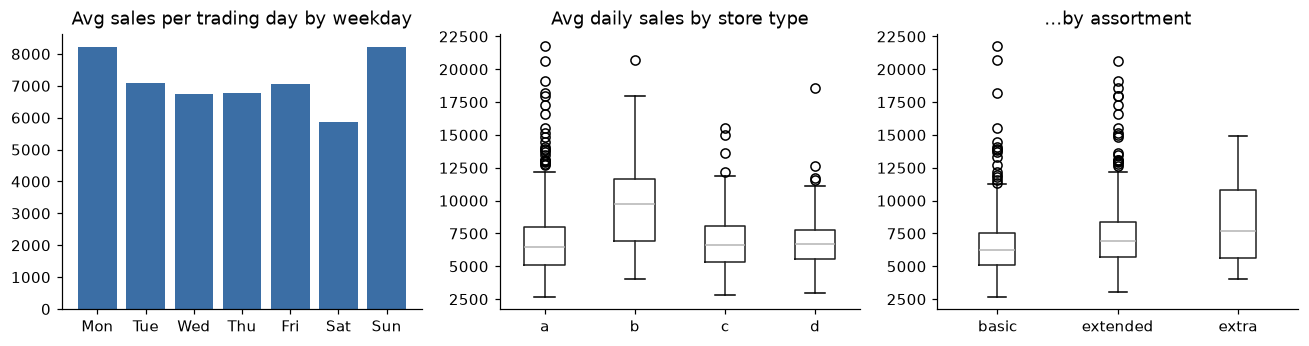

            count  median
store_type               
a             602  6481.0
b              17  9745.0
c             148  6646.0
d             348  6695.0


In [4]:
dow = q('''
    select day_of_week, avg(sales_amount) as avg_sales,
           avg(case when is_promo then 1.0 else 0 end) as promo_share
    from marts.fct_sales_daily where is_open and not is_zero_sales_while_open group by 1 order by 1''')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow["avg_sales"], color="#3b6ea5")
axes[0].set_title("Avg sales per trading day by weekday")
by_type = features.join(stores["store_type"])
by_type.boxplot("avg_daily_sales", by="store_type", ax=axes[1], grid=False)
axes[1].set_title("Avg daily sales by store type"); axes[1].set_xlabel("")
by_assort = features.join(stores["assortment_level"])
by_assort.boxplot("avg_daily_sales", by="assortment_level", ax=axes[2], grid=False)
axes[2].set_title("…by assortment"); axes[2].set_xlabel("")
fig.suptitle(""); fig.tight_layout(); fig.savefig(FIG / "eda_weekday_type_assortment.png"); plt.show()
print(by_type.groupby("store_type")["avg_daily_sales"].agg(["count", "median"]).round(0))

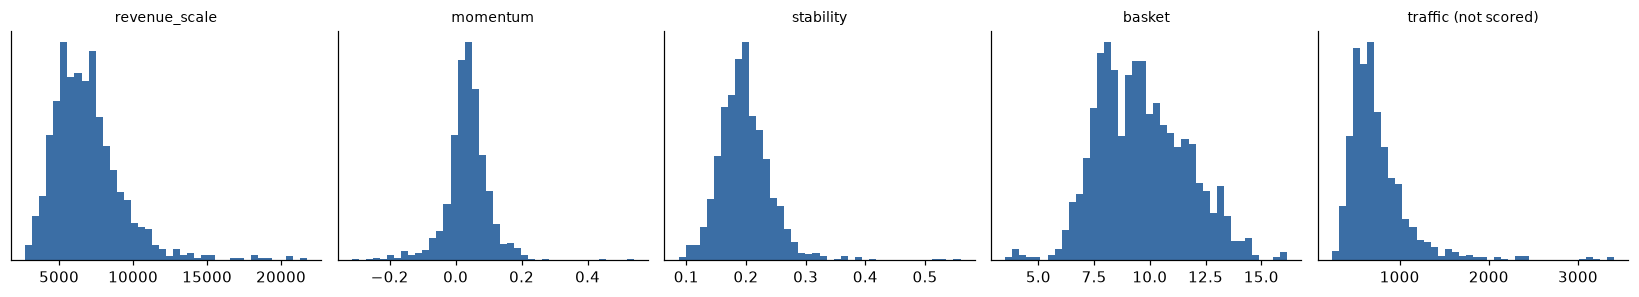

,count,mean,std,min,25%,50%,75%,max
avg_daily_sales,1115.0,6934.632,2383.983,2703.740,5322.300,6589.950,7964.200,21757.480
sales_growth_yoy,1115.0,0.036,0.065,-0.315,0.006,0.036,0.066,0.540
weekly_sales_cv,1115.0,0.198,0.045,0.087,0.170,0.195,0.222,0.559
avg_sales_per_customer,1115.0,9.644,1.987,3.514,8.132,9.464,10.981,16.163
avg_daily_customers,1115.0,754.565,353.389,240.180,541.465,678.670,866.200,3403.460


In [5]:
cols = {f.name: f.column for f in FACTORS} | {"traffic (not scored)": "avg_daily_customers"}
fig, axes = plt.subplots(1, len(cols), figsize=(15, 2.8))
for ax, (name, col) in zip(axes, cols.items()):
    ax.hist(features[col], bins=40, color="#3b6ea5"); ax.set_title(name, fontsize=9); ax.set_yticks([])
fig.tight_layout(); fig.savefig(FIG / "factor_distributions.png"); plt.show()
features[list(cols.values())].describe().T.round(3)

### Why traffic is *not* a scoring factor
Revenue per day ≈ customers per day × sales per customer. If revenue, traffic and basket were all
scored, traffic would be counted twice (directly and inside revenue). The correlation matrix
confirms it: revenue and traffic move together, while basket carries information revenue does not.

In [6]:
corr = features[list(cols.values())].corr(method="spearman")
RESULTS["spearman_revenue_traffic"] = round(float(corr.loc["avg_daily_sales", "avg_daily_customers"]), 3)
RESULTS["spearman_revenue_basket"] = round(float(corr.loc["avg_daily_sales", "avg_sales_per_customer"]), 3)
corr.round(2)

,avg_daily_sales,sales_growth_yoy,weekly_sales_cv,avg_sales_per_customer,avg_daily_customers
avg_daily_sales,1.00,-0.06,-0.12,0.07,0.80
sales_growth_yoy,-0.06,1.00,-0.01,0.16,-0.13
weekly_sales_cv,-0.12,-0.01,1.00,0.06,-0.13
avg_sales_per_customer,0.07,0.16,0.06,1.00,-0.50
avg_daily_customers,0.80,-0.13,-0.13,-0.50,1.00


## 3. Hypothesis test: does a nearby competitor mean lower sales?

The intuitive story is that a competitor next door steals sales. The data hint otherwise
(median sales are *higher* for stores with a competitor under 500 m). We test it formally,
deciding the method before looking at the p-value:

* **Groups** — stores whose nearest competitor is `< 500 m` vs `>= 10 km` (`dim_store.competition_distance_band`).
* **Metric** — `avg_daily_sales` (per trading day, from `mart_store_features`).
* **H0** — the two groups' sales distributions are the same. **H1** — they differ (two-sided).
* **Test** — Mann–Whitney U: store sales are right-skewed with outliers, so a rank test is safer than a t-test.
* **α = 0.05.** Effect size reported as rank-biserial correlation and a bootstrap 95% CI on the
  difference in medians, because "significant" alone says nothing about size.

In [7]:
data = features.join(stores["competition_distance_band"]).join(stores["store_type"])
near = data.loc[data["competition_distance_band"] == "< 500 m", "avg_daily_sales"].astype(float)
far = data.loc[data["competition_distance_band"] == ">= 10 km", "avg_daily_sales"].astype(float)

u, p = stats.mannwhitneyu(near, far, alternative="two-sided")
rank_biserial = 2 * u / (len(near) * len(far)) - 1

rng = np.random.default_rng(42)
boot = np.array([np.median(rng.choice(near, len(near))) - np.median(rng.choice(far, len(far)))
                 for _ in range(10_000)])
ci = np.percentile(boot, [2.5, 97.5])

RESULTS["hypothesis_competition"] = {
    "n_near": int(len(near)), "n_far": int(len(far)),
    "median_near": round(float(near.median()), 0), "median_far": round(float(far.median()), 0),
    "median_diff": round(float(near.median() - far.median()), 0),
    "median_diff_ci95": [round(float(ci[0]), 0), round(float(ci[1]), 0)],
    "mann_whitney_u": float(u), "p_value": float(p), "rank_biserial": round(float(rank_biserial), 3),
    "median_customers_near": round(float(data.loc[near.index, "avg_daily_customers"].median()), 0),
    "median_customers_far": round(float(data.loc[far.index, "avg_daily_customers"].median()), 0),
}
pd.Series(RESULTS["hypothesis_competition"])

n_near                               218
n_far                                187
median_near                       7017.0
median_far                        6675.0
median_diff                        341.0
median_diff_ci95         [-214.0, 784.0]
mann_whitney_u                   22649.0
p_value                         0.053725
rank_biserial                      0.111
median_customers_near              868.0
median_customers_far               651.0
dtype: object

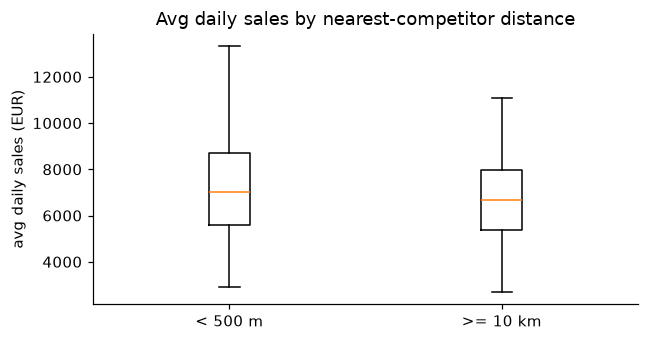

count            median         
competition_distance_band < 500 m >= 10 km  < 500 m >= 10 km
store_type                                                  
a                           156.0     95.0   7107.0   6462.0
b                             4.0      NaN  11432.0      NaN
c                            38.0     11.0   6879.0   7986.0
d                            20.0     81.0   6360.0   6896.0

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.boxplot([near, far], tick_labels=["< 500 m", ">= 10 km"], showfliers=False)
ax.set_ylabel("avg daily sales (EUR)"); ax.set_title("Avg daily sales by nearest-competitor distance")
fig.tight_layout(); fig.savefig(FIG / "competition_hypothesis.png"); plt.show()

# Confounding check: is the difference just a store-type mix effect?
strat = (data[data["competition_distance_band"].isin(["< 500 m", ">= 10 km"])]
         .groupby(["store_type", "competition_distance_band"])["avg_daily_sales"]
         .agg(["count", "median"]).unstack().round(0))
RESULTS["hypothesis_competition_by_type"] = json.loads(strat.to_json())
strat

In [9]:
h = RESULTS["hypothesis_competition"]
verdict = "reject H0" if h["p_value"] < 0.05 else "fail to reject H0"
print(f"Mann-Whitney U = {h['mann_whitney_u']:.0f}, p = {h['p_value']:.4f} -> {verdict} at alpha = 0.05")
print(f"median(<500 m) - median(>=10 km) = {h['median_diff']:.0f} EUR/day, 95% CI {h['median_diff_ci95']}")
print(f"rank-biserial r = {h['rank_biserial']} (|r| < 0.1 negligible, ~0.3 medium)")
RESULTS["hypothesis_competition"]["verdict"] = verdict

# Does the direction survive within each store type? (store types with both groups present)
med = strat["median"].dropna()
flips = {t: ("near > far" if r["< 500 m"] > r[">= 10 km"] else "near < far") for t, r in med.iterrows()}
mix_near = data.loc[near.index, "store_type"].value_counts(normalize=True).round(2).to_dict()
mix_far = data.loc[far.index, "store_type"].value_counts(normalize=True).round(2).to_dict()
RESULTS["hypothesis_competition"].update(direction_by_store_type=flips, type_mix_near=mix_near,
                                         type_mix_far=mix_far)
print("direction within store type:", flips)
print("store-type mix  near:", mix_near, " far:", mix_far)

Mann-Whitney U = 22649, p = 0.0537 -> fail to reject H0 at alpha = 0.05
median(<500 m) - median(>=10 km) = 341 EUR/day, 95% CI [-214.0, 784.0]
rank-biserial r = 0.111 (|r| < 0.1 negligible, ~0.3 medium)
direction within store type: {'a': 'near > far', 'c': 'near < far', 'd': 'near < far'}
store-type mix  near: {'a': 0.72, 'c': 0.17, 'd': 0.09, 'b': 0.02}  far: {'a': 0.51, 'd': 0.43, 'c': 0.06}


**Reading it.** This is observational data. Stores with a competitor under 500 m are
disproportionately in dense locations that also bring foot traffic (compare `median_customers_near`
vs `median_customers_far` above), and the two groups have a different store-type mix. The
within-type comparison checks whether the pooled direction survives once type is held fixed; when
it does not, the pooled gap is at least partly a mix effect (Simpson's-paradox pattern). So the test
can tell us
whether the *association* is real, not that competitors cause higher sales. The stratified table
above is the first check on that; a causal answer would need something like stores whose
competitor *opened* during the window (difference-in-differences on `competition_open_since_date`).
**Implication for tiering:** competition distance is not used as a scoring factor — its direction
is ambiguous and it describes location, not store performance.

## 4. Tiering model

In [10]:
weights = pd.DataFrame([{"factor": f.name, "metric": f.column, "weight": f.weight,
                         "direction": "higher is better" if f.higher_is_better else "lower is better",
                         "why": f.rationale} for f in FACTORS])
RESULTS["weights"] = {f.name: f.weight for f in FACTORS}
RESULTS["tier_shares"] = dict(TIER_SHARES)
weights

,factor,metric,weight,direction,why
0,revenue_scale,avg_daily_sales,0.40,higher is better,Average sales per trading day: the outcome the...
1,momentum,sales_growth_yoy,0.25,higher is better,H1-2015 vs H1-2014 like-for-like growth: where...
2,stability,weekly_sales_cv,0.20,lower is better,Coefficient of variation of weekly sales: pred...
3,basket,avg_sales_per_customer,0.15,higher is better,"Sales per customer: visit quality, the part of..."


In [11]:
scored = score_stores(features)
bounds = scored.groupby("tier")["score"].agg(["count", "min", "max", "median"]).round(1)
RESULTS["tier_score_ranges"] = json.loads(bounds.to_json())
bounds

,count,min,max,median
tier,,,,
A,223,64.8,93.4,71.1
B,334,50.2,64.7,56.8
C,335,35.6,50.2,43.7
D,223,7.8,35.6,28.7


In [12]:
profile = (features.join(scored[["tier"]]).groupby("tier")
           [[f.column for f in FACTORS] + ["avg_daily_customers"]].median().round(3))
mix = pd.crosstab(scored["tier"], stores["store_type"], normalize="index").round(2)
display(profile); display(mix)

,avg_daily_sales,sales_growth_yoy,weekly_sales_cv,avg_sales_per_customer,avg_daily_customers
tier,,,,,
A,8817.050,0.060,0.170,10.510,819.480
B,7109.925,0.041,0.190,10.013,704.185
C,5865.120,0.032,0.201,9.306,621.000
D,4902.340,0.006,0.218,8.320,571.260


store_type,a,b,c,d
tier,,,,
A,0.44,0.04,0.09,0.43
B,0.49,0.01,0.12,0.38
C,0.50,0.01,0.19,0.30
D,0.77,0.00,0.11,0.11


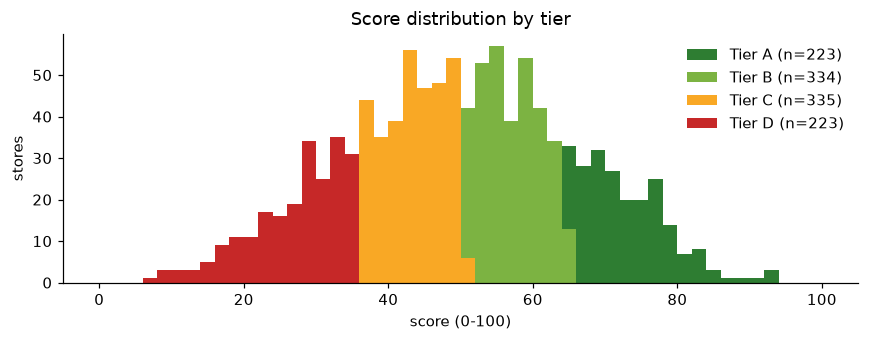

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.2))
colors = {"A": "#2e7d32", "B": "#7cb342", "C": "#f9a825", "D": "#c62828"}
for t in "ABCD":
    s = scored.loc[scored["tier"] == t, "score"]
    ax.hist(s, bins=np.arange(0, 101, 2), color=colors[t], label=f"Tier {t} (n={len(s)})")
ax.set_xlabel("score (0-100)"); ax.set_ylabel("stores"); ax.legend(frameon=False)
ax.set_title("Score distribution by tier")
fig.tight_layout(); fig.savefig(FIG / "tier_scores.png"); plt.show()

## 5. Sensitivity: does a store's tier hinge on the exact weights?
Weights are a judgement call, so we stress them: 1,000 random weight vectors drawn from a
Dirichlet centred on the chosen weights (each weight typically moves by a few points), re-tier
every store each time, and measure how often it keeps its tier.

In [14]:
stability = weight_sensitivity(features, n_draws=1000)
scored = scored.join(stability)
# Publish the uncertainty instead of hiding it: a store that keeps its tier in < 80% of plausible
# weightings is reported as borderline (e.g. "B, borderline A/B") rather than as a crisp tier.
scored["is_borderline"] = scored["tier_stability"] < 0.8
RESULTS["sensitivity"] = {
    "borderline_stores": int(scored["is_borderline"].sum()),
    "share_stores_stable_ge_90pct": round(float((stability >= 0.9).mean()), 3),
    "share_stores_stable_ge_80pct": round(float((stability >= 0.8).mean()), 3),
    "median_stability": round(float(stability.median()), 3),
    "n_draws": 1000,
}
print(RESULTS["sensitivity"])
scored.groupby("tier")["tier_stability"].describe()[["mean", "min", "50%"]].round(3)

{'borderline_stores': 357, 'share_stores_stable_ge_90pct': 0.519, 'share_stores_stable_ge_80pct': 0.68, 'median_stability': 0.908, 'n_draws': 1000}


,mean,min,50%
tier,,,
A,0.895,0.493,0.988
B,0.826,0.452,0.862
C,0.824,0.496,0.859
D,0.891,0.447,0.978


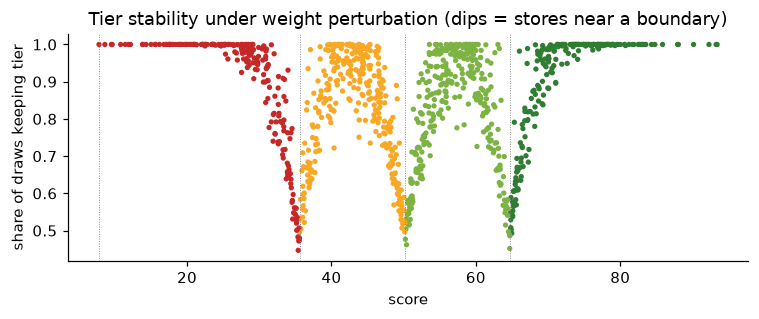

In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(scored["score"], scored["tier_stability"], s=6, c=scored["tier"].map(colors))
for t, lo in scored.groupby("tier")["score"].min().items():
    ax.axvline(lo, color="grey", lw=.6, ls=":")
ax.set_xlabel("score"); ax.set_ylabel("share of draws keeping tier")
ax.set_title("Tier stability under weight perturbation (dips = stores near a boundary)")
fig.tight_layout(); fig.savefig(FIG / "tier_stability.png"); plt.show()

## 6. Defending a single store's tier
`explain_store` returns, for one store: its raw metric values, percentile on each factor, the points
each factor contributed (weight × percentile × 100), the score floor of its tier, how many points
it needs for the next tier, and its weakest factor relative to that factor's weight.

In [16]:
def show(store_id: int) -> dict:
    e = explain_store(store_id, features, scored)
    e["tier_stability"] = round(float(scored.loc[store_id, "tier_stability"]), 3)
    print(f"Store {e['store_id']}: tier {e['tier']}, rank {e['rank']}/{e['of']}, score {e['score']} "
          f"(tier floor {e['tier_floor']}); next tier {e['next_tier']} needs +{e['points_to_next_tier']} pts; "
          f"weakest factor: {e['weakest_factor']}; keeps tier in {e['tier_stability']:.0%} of weight draws")
    display(pd.DataFrame(e["breakdown"]).set_index("factor"))
    return e

# Boundary case: the tier-B store closest to tier A -- the one a manager is most likely to dispute.
b_stores = scored[scored["tier"] == "B"]
boundary_store = int(b_stores["score"].idxmax())
RESULTS["example_boundary_store"] = show(boundary_store)

Store 236: tier B, rank 224/1115, score 64.72 (tier floor 50.23); next tier A needs +0.04 pts; weakest factor: basket; keeps tier in 49% of weight draws


,metric,value,percentile,weight,points,max_points
factor,,,,,,
revenue_scale,avg_daily_sales,7119.5600,61.0,0.40,24.39,40.0
momentum,sales_growth_yoy,0.0889,84.5,0.25,21.13,25.0
stability,weekly_sales_cv,0.1698,75.0,0.20,15.00,20.0
basket,avg_sales_per_customer,8.2327,27.9,0.15,4.18,15.0


In [17]:
# A reference case: store 1 (first store in the dataset).
RESULTS["example_store_1"] = show(1)

Store 1: tier D, rank 1025/1115, score 27.57 (tier floor 7.8); next tier C needs +8.01 pts; weakest factor: momentum; keeps tier in 98% of weight draws


,metric,value,percentile,weight,points,max_points
factor,,,,,,
revenue_scale,avg_daily_sales,4759.1000,13.9,0.40,5.56,40.0
momentum,sales_growth_yoy,-0.0227,10.9,0.25,2.74,25.0
stability,weekly_sales_cv,0.1727,72.5,0.20,14.50,20.0
basket,avg_sales_per_customer,8.4374,31.8,0.15,4.78,15.0


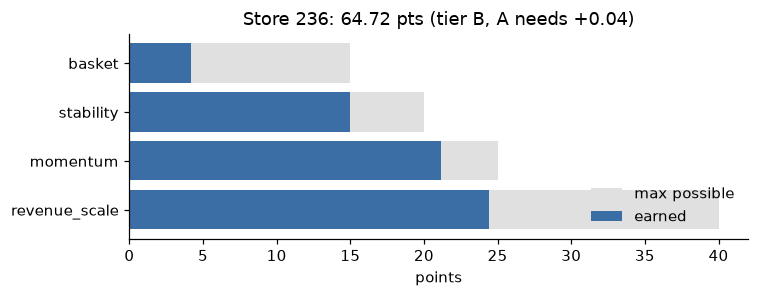

In [18]:
e = RESULTS["example_boundary_store"]
b = pd.DataFrame(e["breakdown"])
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(b["factor"], b["max_points"], color="#e0e0e0", label="max possible")
ax.barh(b["factor"], b["points"], color="#3b6ea5", label="earned")
ax.set_xlabel("points"); ax.legend(frameon=False, loc="lower right")
ax.set_title(f"Store {e['store_id']}: {e['score']} pts (tier {e['tier']}, A needs +{e['points_to_next_tier']})")
fig.tight_layout(); fig.savefig(FIG / "defend_store.png"); plt.show()

**How to defend it in one breath:** *"Store X is tier B because it scores N/100: it earned P points
of a possible 40 on revenue, … It's M points short of tier A; its weakest lever is <factor>. The tier
is robust — it holds in K% of re-weighted scenarios — so this isn't an artefact of our exact weights."*
If a manager disputes it, the conversation moves to the specific factor and the data behind it,
not to the model as a black box.

## 7. Limitations
* **Relative tiers.** A–D are quantile-based, so 20% of stores are always tier D even if every store
  improves. Fine for prioritising attention; not a pass/fail standard.
* **Weights are judgement**, made explicit and stress-tested (section 5), not learned from an outcome.
  With a target (e.g. future profitability) they could be fit and validated out of sample.
* **No profitability data**: revenue is not margin. Rent, staff and shrink are not in the source.
* **Momentum uses one window** (H1-15 vs H1-14); a store refurbished during H1-2014 looks like a
  growth star. Closures over 7 days could be detected from `fct_sales_daily` and excluded.
* **Hypothesis test is observational**: association, not causation (see section 3).

In [19]:
scored_out = scored.reset_index()[["store_id", "rank", "tier", "score", "tier_stability", "is_borderline"]
                                  + [f"{f.name}_points" for f in FACTORS]]
scored_out.round(3).to_csv(ROOT / "analytics" / "store_tiers.csv", index=False)
(ROOT / "analytics" / "results.json").write_text(json.dumps(RESULTS, indent=2, default=str))
conn.close()
print("wrote analytics/store_tiers.csv and analytics/results.json")

wrote analytics/store_tiers.csv and analytics/results.json
